# SECOM SPC + FDC — Analysis Notebook

**Yeshudan Bora · CMU MS AI Engineering — Chemical Engineering**

This notebook walks through the full Statistical Process Control + 
Multivariate Fault Detection pipeline on the SECOM dataset, end to 
end. Each section corresponds to one phase of the project:

1. **Phase 1** — Data ingestion, cleaning, critical-sensor selection
2. **Phase 2** — Univariate SPC: I-MR charts, Nelson rules, Cp/Cpk
3. **Phase 3** — Multivariate FDC: PCA T² + SPE/Q + contribution analysis

Run the cells top-to-bottom. The notebook reads from `data/raw/` and 
writes intermediate artefacts to `data/processed/`.

## 0. Imports & setup

In [1]:
import sys
from pathlib import Path

# Add project root to path so we can import src/ when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RAW = ROOT / 'data' / 'raw'
OUT = ROOT / 'data' / 'processed'
OUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)

Project root: /home/claude/secom-spc-fdc


## Phase 1 — Data ingestion & cleaning

The SECOM dataset has 1,567 wafer runs × 590 sensors, with NaN-encoded 
missing values and a binary pass/fail label. The cleaning pipeline:

1. **Drop sensors with > 50% missing** — broken/offline equipment.
2. **Drop zero-variance sensors** — constants carry no SPC information.
3. **Drop highly correlated sensors (|ρ| > 0.99)** — redundant taps.
4. **Median-impute residual NaNs** in the surviving sensors.

Each threshold corresponds to a real engineering decision and is documented 
in `src/data_loader.py`'s `CleaningConfig` dataclass.

In [2]:
from src.data_loader import load_raw, clean, select_critical_sensors

df = load_raw(RAW / 'secom.data', RAW / 'secom_labels.data')
print(f'Raw shape: {df.shape}')
print(f'Pass / fail counts: {(~df.is_fail).sum()} / {df.is_fail.sum()}')
df.head()

Raw shape: (1567, 593)
Pass / fail counts: 1463 / 104


,label,timestamp,is_fail,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,-1,2008-07-19 11:55:00,False,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,2008-07-19 12:32:00,False,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,2008-07-19 13:17:00,True,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,2008-07-19 14:43:00,False,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,2008-07-19 15:22:00,False,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [3]:
cleaned, report = clean(df)
print(report.summary())

SECOM cleaning report
---------------------
Rows (wafer runs)          : 1567
Sensors raw                : 590
  after missing-rate filter: 562 (-28)
  after variance filter    : 446 (-116)
  after correlation filter : 351 (-95)
Sensors final              : 351

Pass wafers                : 1463
Fail wafers                : 104
Fail rate                  : 6.64%



In [4]:
cleaned.to_parquet(OUT / 'secom_clean.parquet', index=False)
(OUT / 'cleaning_report.txt').write_text(report.summary())
print(f"Wrote {OUT / 'secom_clean.parquet'} ({cleaned.shape[0]} rows × {cleaned.shape[1]} cols)")

Wrote /home/claude/secom-spc-fdc/data/processed/secom_clean.parquet (1567 rows × 354 cols)


### Critical-sensor selection

We rank sensors by absolute Pearson correlation with the fail label and 
keep the top 25. This is supervised feature selection — it uses outcome 
data to decide *what to monitor*, but the FDC model in Phase 3 is then 
fit on a pass-only baseline, so the model itself never sees a failure 
during training. See `reports/methodology_sensor_selection.md` for the 
full discussion and the variance-based robustness check.

In [5]:
critical = select_critical_sensors(cleaned, n=25, method='fail_corr')
(OUT / 'critical_sensors.txt').write_text('\n'.join(critical))
print('Top 25 critical sensors:')
for i, s in enumerate(critical, 1):
    print(f'  {i:2d}. {s}')

Top 25 critical sensors:
   1. sensor_59
   2. sensor_103
   3. sensor_510
   4. sensor_348
   5. sensor_431
   6. sensor_434
   7. sensor_430
   8. sensor_21
   9. sensor_28
  10. sensor_210
  11. sensor_129
  12. sensor_163
  13. sensor_124
  14. sensor_316
  15. sensor_160
  16. sensor_164
  17. sensor_121
  18. sensor_125
  19. sensor_165
  20. sensor_247
  21. sensor_33
  22. sensor_26
  23. sensor_180
  24. sensor_122
  25. sensor_79


## Phase 2 — Univariate SPC

**Baseline split:** first 70% of pass-only wafers (chronologically) form 
the in-control reference. The remaining 30% pass + all 104 fails form the 
monitoring set on which Nelson rules are evaluated. This prevents control 
limits from "seeing" the excursions they are supposed to detect.

**Sigma estimates:**
- σ_within = MR̄ / d₂ (d₂ = 1.128 for n=2 moving ranges) — used for 
  control limits and Cp/Cpk denominators
- σ_overall = std(baseline) — used to set USL / LSL = μ ± 3σ_overall

When σ_within < σ_overall, the process drifts more than its inherent 
noise, and Cp > 1 reflects the gap.

In [6]:
from src.spc import (
    split_baseline_monitoring, fit_control_limits, nelson_rules, run_univariate_spc,
)

baseline, monitoring = split_baseline_monitoring(cleaned, baseline_frac=0.70)
print(f'Baseline (in-control)  : {len(baseline):>4} wafers, {baseline.is_fail.sum()} fails')
print(f'Monitoring (held-out)  : {len(monitoring):>4} wafers, {monitoring.is_fail.sum()} fails')

Baseline (in-control)  : 1024 wafers, 0 fails
Monitoring (held-out)  :  543 wafers, 104 fails


In [7]:
summary, limits_by, rules_by = run_univariate_spc(cleaned, critical)
summary.to_csv(OUT / 'spc_summary.csv', index=False)
summary[['sensor', 'mu', 'mu_monitoring', 'mean_shift_sigma',
         'sigma_within', 'sigma_overall', 'drift_ratio',
         'Cp', 'Cpk_baseline', 'Cpk_monitoring',
         'flagged_points', 'flag_rate']].round(3).head(10)

,sensor,mu,mu_monitoring,mean_shift_sigma,sigma_within,sigma_overall,drift_ratio,Cp,Cpk_baseline,Cpk_monitoring,flagged_points,flag_rate
0,sensor_316,5.767,6.373,0.810,0.749,0.867,1.158,1.158,1.158,0.888,191,0.352
1,sensor_180,18.458,20.060,0.586,2.732,3.142,1.150,1.150,1.150,0.955,110,0.203
2,sensor_28,68.751,70.910,0.852,2.533,3.377,1.333,1.333,1.333,1.049,203,0.374
3,sensor_79,0.008,-0.005,-0.680,0.018,0.024,1.333,1.333,1.333,1.107,270,0.497
4,sensor_21,-5686.155,-5490.257,0.390,502.816,663.334,1.319,1.319,1.319,1.189,206,0.379
5,sensor_210,0.090,0.086,-0.135,0.030,0.042,1.387,1.387,1.387,1.342,116,0.214
6,sensor_348,0.025,0.024,-0.113,0.008,0.011,1.388,1.388,1.388,1.350,101,0.186
7,sensor_103,-0.009,-0.011,-0.556,0.002,0.003,1.588,1.588,1.588,1.403,195,0.359
8,sensor_510,58.864,49.885,-0.349,25.732,40.025,1.555,1.555,1.555,1.439,127,0.234
9,sensor_160,604.971,461.331,-0.372,385.734,620.618,1.609,1.609,1.609,1.485,131,0.241


### Cpk leaderboard

Sorting by `Cpk_monitoring` ascending shows which sensors have lost 
capability during the monitoring window. Anything below 1.0 is no longer 
meeting its natural ±3σ tolerance.

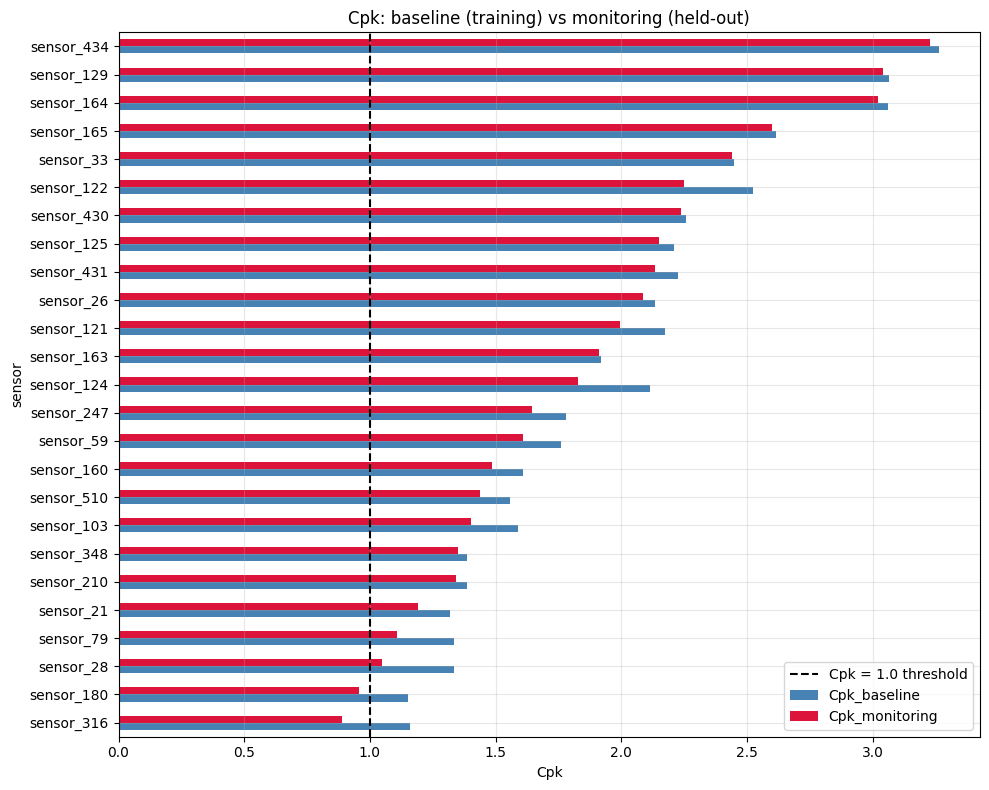

In [8]:
ax = summary.set_index('sensor')[['Cpk_baseline', 'Cpk_monitoring']].plot.barh(
    figsize=(10, 8), color=['steelblue', 'crimson'])
ax.axvline(1.0, color='black', linestyle='--', label='Cpk = 1.0 threshold')
ax.set_xlabel('Cpk')
ax.set_title('Cpk: baseline (training) vs monitoring (held-out)')
ax.legend()
plt.tight_layout()
plt.show()

### Example I-MR chart

Pick the worst-Cpk sensor on the monitoring set and plot its Individuals 
chart with control limits, zone bands, and Nelson-rule violations.

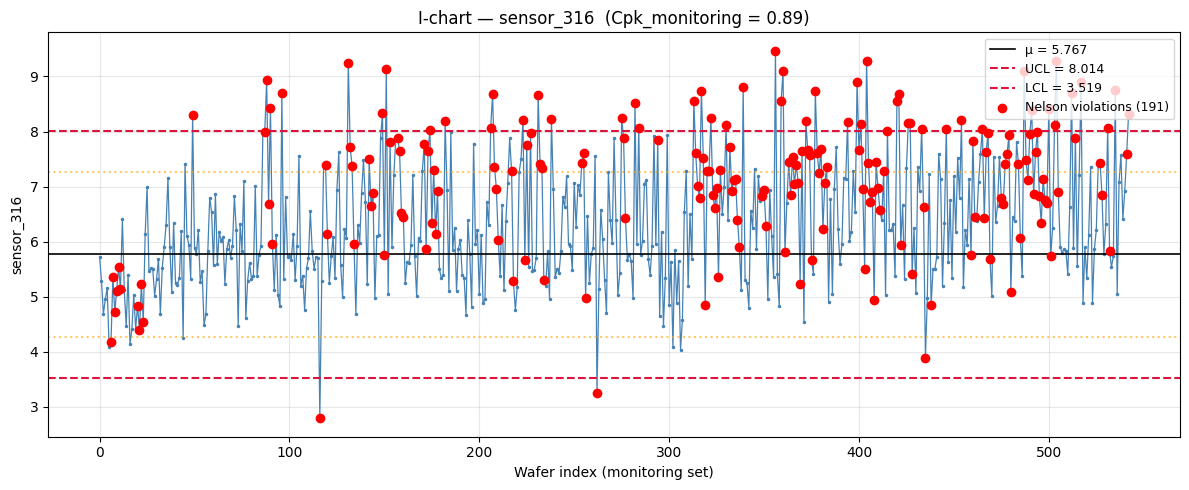

In [9]:
worst_sensor = summary.iloc[0]['sensor']
lim = limits_by[worst_sensor]
rules = rules_by[worst_sensor]
values = monitoring[worst_sensor].to_numpy()
violations = rules.any_violation()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(values))
ax.plot(x, values, color='steelblue', linewidth=0.9, marker='.', markersize=3)
ax.axhline(lim.mu,    color='black',    linewidth=1.2, label=f'μ = {lim.mu:.3f}')
ax.axhline(lim.ucl_i, color='crimson',  linestyle='--', label=f'UCL = {lim.ucl_i:.3f}')
ax.axhline(lim.lcl_i, color='crimson',  linestyle='--', label=f'LCL = {lim.lcl_i:.3f}')
ax.axhline(lim.zone_a_upper, color='orange', linestyle=':', alpha=0.6)
ax.axhline(lim.zone_a_lower, color='orange', linestyle=':', alpha=0.6)
ax.scatter(x[violations], values[violations], color='red', zorder=5,
           label=f'Nelson violations ({violations.sum()})')
ax.set_title(f'I-chart — {worst_sensor}  (Cpk_monitoring = {summary.iloc[0]["Cpk_monitoring"]:.2f})')
ax.set_xlabel('Wafer index (monitoring set)')
ax.set_ylabel(worst_sensor)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### Nelson rule violation breakdown

Aggregating the violation counts across all monitored sensors shows 
*which* failure patterns are most common in this fab. In SECOM the 
dominant patterns are Rule 5 (2-of-3 in zone A) and Rule 6 (4-of-5 in 
zone B) — both signal a meaningful drift in the process mean rather 
than isolated outliers.

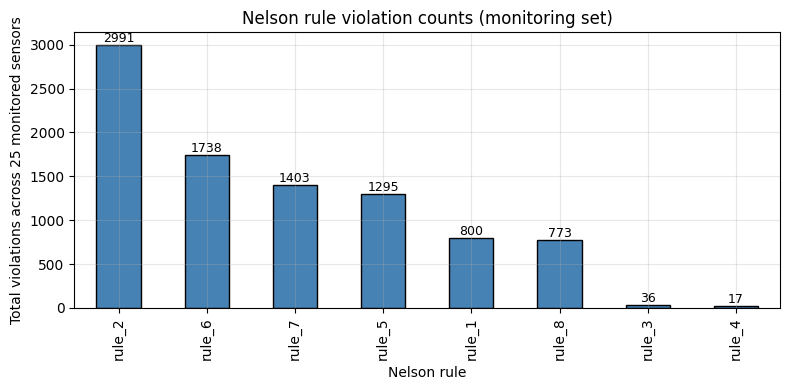

In [10]:
rule_cols = [f'rule_{i}' for i in range(1, 9)]
totals = summary[rule_cols].sum().sort_values(ascending=False)
ax = totals.plot.bar(figsize=(8, 4), color='steelblue', edgecolor='black')
ax.set_xlabel('Nelson rule')
ax.set_ylabel('Total violations across 25 monitored sensors')
ax.set_title('Nelson rule violation counts (monitoring set)')
for i, v in enumerate(totals):
    ax.text(i, v, f'{int(v)}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Phase 3 — Multivariate FDC (PCA T² + SPE/Q)

Univariate SPC misses correlated excursions: wafers where every sensor 
stays within its own ±3σ band but the *joint* state has wandered out of 
the operating envelope. PCA-based FDC catches these with two 
complementary statistics:

- **Hotelling's T²** — distance from the origin *inside* the K-component 
  model subspace, normalized by each PC's variance. Catches deviations 
  along known correlation directions.
- **SPE / Q** — squared residual *orthogonal* to the model subspace. 
  Catches wafers whose correlation structure breaks down — sensors that 
  normally move together suddenly don't.

**Control limits at α = 0.01 (99% confidence):**
- T² limit: scaled F-distribution closed form
- SPE limit: Jackson-Mudholkar (1979) closed form

In [11]:
from src.fdc import (
    fit_pca, score, t2_contributions, spe_contributions,
    evaluate_against_labels,
)

model = fit_pca(baseline, critical, var_threshold=0.90, alpha=0.01)
print(f'PCA model fitted on {model.N_baseline} in-control wafers, '
      f'{len(model.sensor_cols)} sensors')
print(f'Components retained (K) : {model.K} (>= 90% variance)')
print(f'Variance explained      : '
      f'{model.explained_variance_ratio[:model.K].sum():.3f}')
print(f'T^2 limit (99%)         : {model.t2_limit:.3f}')
print(f'SPE limit (99%)         : {model.spe_limit:.3f}')

PCA model fitted on 1024 in-control wafers, 25 sensors
Components retained (K) : 12 (>= 90% variance)
Variance explained      : 0.903
T^2 limit (99%)         : 26.741
SPE limit (99%)         : 6.626


### Scree plot

Cumulative variance vs number of components. The vertical line marks 
the cutoff at K = 12; the horizontal line marks the 90% threshold.

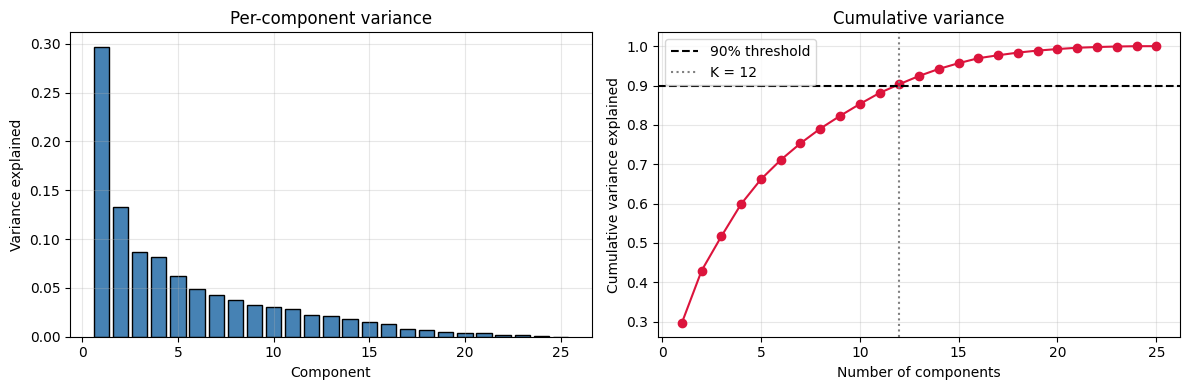

In [12]:
evr = model.explained_variance_ratio
cum = np.cumsum(evr)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, len(evr) + 1), evr, color='steelblue', edgecolor='black')
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance explained')
ax1.set_title('Per-component variance')
ax2.plot(range(1, len(cum) + 1), cum, marker='o', color='crimson')
ax2.axhline(0.90, color='black', linestyle='--', label='90% threshold')
ax2.axvline(model.K, color='gray', linestyle=':', label=f'K = {model.K}')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative variance explained')
ax2.set_title('Cumulative variance')
ax2.legend()
plt.tight_layout()
plt.show()

### T² and SPE control charts

Score every wafer in the monitoring set, plot T² and SPE side-by-side 
with their 99% limits. Real fail wafers are shown in red. The mix of 
T²-only / SPE-only / both alarms is itself diagnostic — different 
alarm types correspond to different excursion modes.

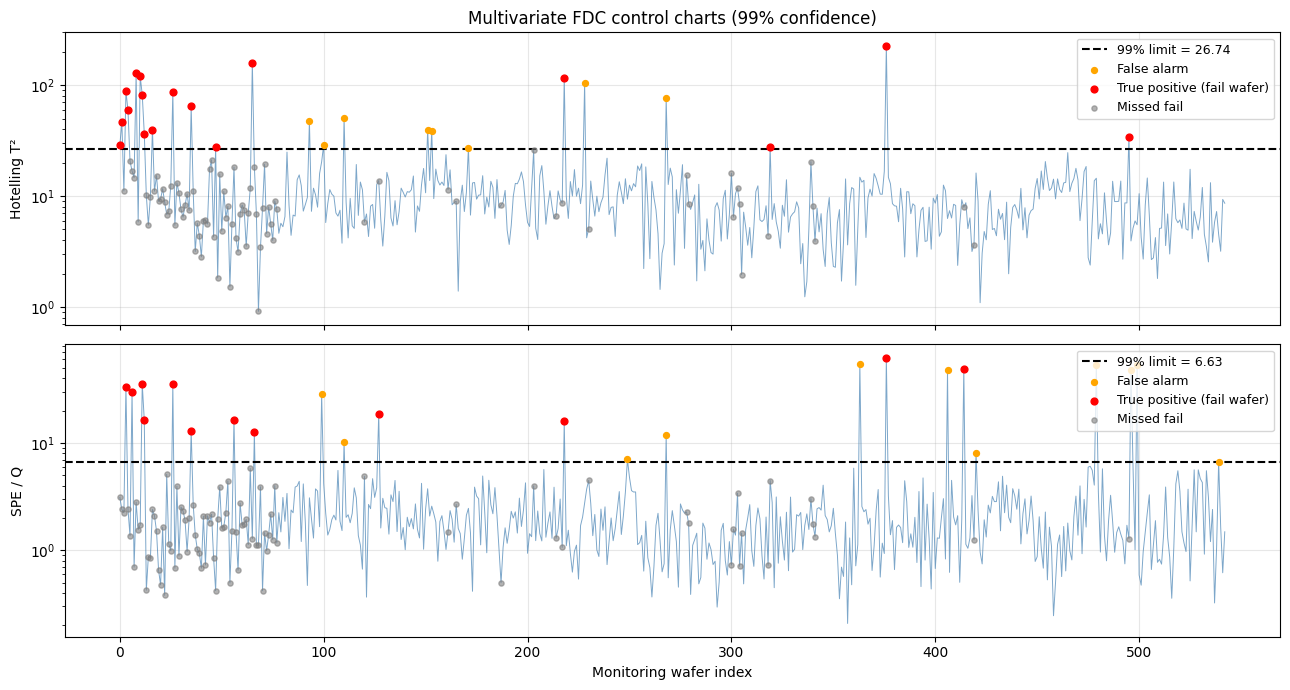

In [13]:
scores = score(model, monitoring)
is_fail = monitoring['is_fail'].to_numpy()
x = np.arange(len(monitoring))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, stat, limit, name in zip(
    axes,
    [scores.t2, scores.spe],
    [scores.t2_limit, scores.spe_limit],
    ['Hotelling T²', 'SPE / Q'],
):
    ax.plot(x, stat, color='steelblue', linewidth=0.7, alpha=0.7)
    ax.axhline(limit, color='black', linestyle='--', label=f'99% limit = {limit:.2f}')
    above = stat > limit
    ax.scatter(x[above & ~is_fail], stat[above & ~is_fail], color='orange', s=18, label='False alarm', zorder=4)
    ax.scatter(x[above &  is_fail], stat[above &  is_fail], color='red',    s=24, label='True positive (fail wafer)', zorder=5)
    ax.scatter(x[~above & is_fail], stat[~above & is_fail], color='gray',   s=14, alpha=0.6, label='Missed fail', zorder=3)
    ax.set_ylabel(name)
    ax.set_yscale('log')
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Monitoring wafer index')
axes[0].set_title('Multivariate FDC control charts (99% confidence)')
plt.tight_layout()
plt.show()

### Detection scorecard

Treat fail wafers as positives and the alarm flag (T² OR SPE above limit) 
as the predictor. The headline number is **precision** — when the system 
raises an alarm, how often is it right? Compare against the base-rate 
fail probability (104 / 543 ≈ 19.2%).

In [14]:
metrics = evaluate_against_labels(scores, is_fail)
print('Confusion matrix on monitoring set:')
print(f'  TP : {metrics["TP"]:>4}    FP : {metrics["FP"]:>4}')
print(f'  FN : {metrics["FN"]:>4}    TN : {metrics["TN"]:>4}')
print()
print(f'  Recall (TPR)        : {metrics["TPR (recall)"]:.3f}')
print(f'  False alarm rate    : {metrics["FPR (false alarm)"]:.3f}')
print(f'  Precision           : {metrics["precision"]:.3f}')
print(f'  F1                  : {metrics["F1"]:.3f}')
base_rate = is_fail.mean()
print(f'  Base-rate fail prob : {base_rate:.3f}')
print(f'  Precision lift      : {metrics["precision"] / base_rate:.2f}×')
print()
print(f'  T^2-only alarms     : {metrics["t2_only_alarms"]}')
print(f'  SPE-only alarms     : {metrics["spe_only_alarms"]}')
print(f'  Both-stat alarms    : {metrics["both_alarms"]}')

Confusion matrix on monitoring set:
  TP :   22    FP :   17
  FN :   82    TN :  422

  Recall (TPR)        : 0.212
  False alarm rate    : 0.039
  Precision           : 0.564
  F1                  : 0.308
  Base-rate fail prob : 0.192
  Precision lift      : 2.95×

  T^2-only alarms     : 25
  SPE-only alarms     : 23
  Both-stat alarms    : 9


### Root-cause: contribution analysis on the worst alarm

When a wafer trips the limit, decompose T² and SPE into per-sensor 
contributions. The MacGregor decomposition gives:

$$ \text{contrib}_j (T^2) = \sum_{k=1}^K \frac{P_{jk} \, x_j \, t_k}{\lambda_k} \quad,\quad \text{contrib}_j(\text{SPE}) = (x_j - \hat{x}_j)^2 $$

and the contributions sum exactly to the parent statistic — verified in 
`tests/test_fdc.py`. The top-N contributors are the sensor(s) the 
process engineer should look at first.

Worst T^2 wafer       : monitoring index 376, timestamp 2008-10-07 13:10:00
  T^2 = 227.88 (limit 26.74)
  SPE = 62.19 (limit 6.63)
  Actual outcome    : FAIL


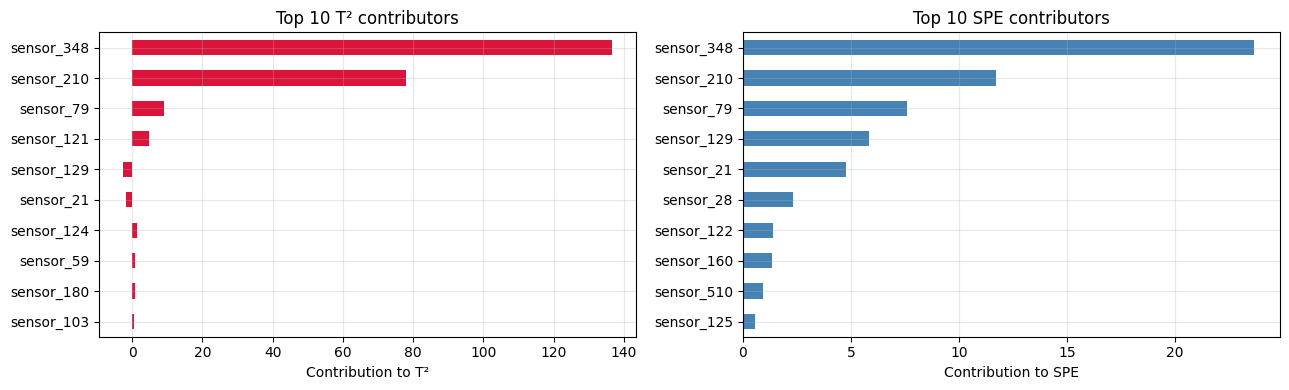

In [15]:
worst_idx = int(np.argmax(scores.t2))
wafer = monitoring.iloc[worst_idx]
ct2 = t2_contributions(model, wafer)
cspe = spe_contributions(model, wafer)

print(f'Worst T^2 wafer       : monitoring index {worst_idx}, '
      f'timestamp {wafer["timestamp"]}')
print(f'  T^2 = {scores.t2[worst_idx]:.2f} (limit {model.t2_limit:.2f})')
print(f'  SPE = {scores.spe[worst_idx]:.2f} (limit {model.spe_limit:.2f})')
print(f'  Actual outcome    : '
      f'{"FAIL" if wafer["is_fail"] else "pass"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ct2.head(10).plot.barh(ax=axes[0], color='crimson')
axes[0].set_title('Top 10 T² contributors')
axes[0].invert_yaxis()
axes[0].set_xlabel('Contribution to T²')
cspe.head(10).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 SPE contributors')
axes[1].invert_yaxis()
axes[1].set_xlabel('Contribution to SPE')
plt.tight_layout()
plt.show()

### Methodology robustness check

Re-run the entire FDC pipeline using **variance-only** (unsupervised) 
sensor selection. The two methods share only 2 of 25 sensors. The 
supervised run dominates — fail-correlated sensors carry the most 
signal — but the unsupervised run is fully leakage-free. Both numbers 
are documented in `reports/methodology_sensor_selection.md`.

In [16]:
from src.fdc import run_fdc

crit_var = select_critical_sensors(cleaned, n=25, method='variance')
_, _, scores_var, m_var = run_fdc(cleaned, crit_var)
_, _, _, m_corr = run_fdc(cleaned, critical)

comparison = pd.DataFrame({
    'fail_corr (headline)': {
        'TPR': m_corr['TPR (recall)'],
        'FPR': m_corr['FPR (false alarm)'],
        'Precision': m_corr['precision'],
        'F1': m_corr['F1'],
    },
    'variance (robustness)': {
        'TPR': m_var['TPR (recall)'],
        'FPR': m_var['FPR (false alarm)'],
        'Precision': m_var['precision'],
        'F1': m_var['F1'],
    },
}).T.round(3)
comparison

,TPR,FPR,Precision,F1
fail_corr (headline),0.212,0.039,0.564,0.308
variance (robustness),0.144,0.109,0.238,0.180


## Summary

| Phase | Output |
| --- | --- |
| Phase 1 | 590 → 351 sensors after cleaning, 25 selected for monitoring |
| Phase 2 | I-MR + Nelson + Cp/Cpk; 2 sensors with Cpk_monitoring < 1.0 |
| Phase 3 | PCA T² + SPE; **56% precision @ 3.9% FPR (2.95× base-rate lift)** |
| Phase 4 | Alarm catalog + Pareto contributions + 'usual suspect' leaderboard |
| Phase 5 | EWMA R2R controller; 50–65% of Nelson violations prevented |
| Phase 6 | PostgreSQL schema + SparkSQL ingest; SQL-sourced pipeline matches file-sourced bit-for-bit |

The full module-level details are in `src/`, every module has unit 
tests in `tests/` (30 tests, all passing — 26 if Postgres is not 
available), the methodology discussion is in 
`reports/methodology_sensor_selection.md`, and the SQL/Spark 
architecture is documented in `reports/sql_data_layer.md`.